In [1]:
#| include: false

# /// script
# requires-python = ">=3.10"
# dependencies = [
#   "matplotlib",
#   "numpy",
#   "pandas",
#   "pymc",
#   "scipy",
#   "seaborn",
# ]
# ///


We read back the Oceanic tools data with geographic coordinates and a distance matrix to model spatial correlation between island societies using a Gaussian Process covariance structure.

In [2]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("poster")
import pymc as pm
import arviz as az

## Reading in our data

We read back the Oceanic tools data

In [3]:
df = pd.read_csv("data/Kline2.csv", sep=';')
df.head()

,culture,population,contact,total_tools,mean_TU,lat,lon,lon2,logpop
0,Malekula,1100,low,13,3.2,-16.3,167.5,-12.5,7.003065
1,Tikopia,1500,low,22,4.7,-12.3,168.8,-11.2,7.313220
2,Santa Cruz,3600,low,24,4.0,-10.7,166.0,-14.0,8.188689
3,Yap,4791,high,43,5.0,9.5,138.1,-41.9,8.474494
4,Lau Fiji,7400,high,33,5.0,-17.7,178.1,-1.9,8.909235


And center it

In [4]:
df['logpop_c'] = df.logpop - df.logpop.mean()

In [5]:
df.head()

,culture,population,contact,total_tools,mean_TU,lat,lon,lon2,logpop,logpop_c
0,Malekula,1100,low,13,3.2,-16.3,167.5,-12.5,7.003065,-1.973939
1,Tikopia,1500,low,22,4.7,-12.3,168.8,-11.2,7.313220,-1.663784
2,Santa Cruz,3600,low,24,4.0,-10.7,166.0,-14.0,8.188689,-0.788316
3,Yap,4791,high,43,5.0,9.5,138.1,-41.9,8.474494,-0.502510
4,Lau Fiji,7400,high,33,5.0,-17.7,178.1,-1.9,8.909235,-0.067769


And read in the distance matrix

In [6]:
dfd = pd.read_csv("data/distmatrix.csv", header=None)
dij=dfd.values
dij

array([[0.   , 0.475, 0.631, 4.363, 1.234, 2.036, 3.178, 2.794, 1.86 ,
        5.678],
       [0.475, 0.   , 0.315, 4.173, 1.236, 2.007, 2.877, 2.67 , 1.965,
        5.283],
       [0.631, 0.315, 0.   , 3.859, 1.55 , 1.708, 2.588, 2.356, 2.279,
        5.401],
       [4.363, 4.173, 3.859, 0.   , 5.391, 2.462, 1.555, 1.616, 6.136,
        7.178],
       [1.234, 1.236, 1.55 , 5.391, 0.   , 3.219, 4.027, 3.906, 0.763,
        4.884],
       [2.036, 2.007, 1.708, 2.462, 3.219, 0.   , 1.801, 0.85 , 3.893,
        6.653],
       [3.178, 2.877, 2.588, 1.555, 4.027, 1.801, 0.   , 1.213, 4.789,
        5.787],
       [2.794, 2.67 , 2.356, 1.616, 3.906, 0.85 , 1.213, 0.   , 4.622,
        6.722],
       [1.86 , 1.965, 2.279, 6.136, 0.763, 3.893, 4.789, 4.622, 0.   ,
        5.037],
       [5.678, 5.283, 5.401, 7.178, 4.884, 6.653, 5.787, 6.722, 5.037,
        0.   ]])

## Implementing the simple tools:logpop model and varying intercepts models

In [7]:
import pytensor.tensor as pt

In [8]:
with pm.Model() as m2c_onlyp:
    betap = pm.Normal("betap", 0, 1)
    alpha = pm.Normal("alpha", 0, 10)
    loglam = alpha + betap*df.logpop_c
    y = pm.Poisson("ntools", mu=pt.exp(loglam), observed=df.total_tools)
    trace2c_onlyp = pm.sample(6000, tune=1000)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [betap, alpha]


/Users/rahul/Library/Caches/uv/archive-v0/aTiHGxSE8gD8G3bEQyxJO/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 6_000 draw iterations (4_000 + 24_000 draws total) took 2 seconds.


In [9]:
az.summary(trace2c_onlyp)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betap,0.239,0.031,0.179,0.297,0.0,0.0,20521.0,16397.0,1.0
alpha,3.478,0.058,3.372,3.588,0.0,0.0,20922.0,16520.0,1.0


Notice that $\beta_P$ has a value around 0.24

We also implement the varying intercepts per society model from before

In [10]:
with pm.Model() as m3c:
    betap = pm.Normal("betap", 0, 1)
    alpha = pm.Normal("alpha", 0, 10)
    sigmasoc = pm.HalfCauchy("sigmasoc", 1)
    alphasoc = pm.Normal("alphasoc", 0, sigmasoc, shape=df.shape[0])
    loglam = alpha + alphasoc + betap*df.logpop_c 
    y = pm.Poisson("ntools", mu=pt.exp(loglam), observed=df.total_tools)
with m3c:
    trace3 = pm.sample(6000, tune=1000, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [betap, alpha, sigmasoc, alphasoc]


/Users/rahul/Library/Caches/uv/archive-v0/aTiHGxSE8gD8G3bEQyxJO/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 6_000 draw iterations (4_000 + 24_000 draws total) took 5 seconds.


There were 10 divergences after tuning. Increase `target_accept` or reparameterize.


In [11]:
az.summary(trace3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betap,0.261,0.081,0.107,0.416,0.001,0.001,9947.0,9891.0,1.0
alpha,3.443,0.120,3.211,3.667,0.001,0.001,7646.0,8098.0,1.0
alphasoc[0],-0.201,0.241,-0.665,0.243,0.002,0.002,12562.0,11942.0,1.0
alphasoc[1],0.042,0.221,-0.367,0.478,0.002,0.002,11734.0,10870.0,1.0
alphasoc[2],-0.048,0.195,-0.418,0.331,0.002,0.002,12818.0,12931.0,1.0
alphasoc[3],0.325,0.189,-0.025,0.678,0.002,0.002,7467.0,9482.0,1.0
alphasoc[4],0.044,0.176,-0.281,0.391,0.002,0.001,12480.0,11816.0,1.0
alphasoc[5],-0.317,0.208,-0.713,0.049,0.002,0.002,11430.0,12974.0,1.0
alphasoc[6],0.145,0.171,-0.169,0.478,0.002,0.001,11496.0,11783.0,1.0
alphasoc[7],-0.171,0.182,-0.533,0.151,0.002,0.001,12357.0,13019.0,1.0


## A model with a custom covariance matrix

The assumption here now is that the intercepts for these various societies are correlated...

We use a custom covariance matrix which inverse-square weights distance

![GP covariance matrix: squared-exponential kernel weighted by geographic distance, plus a noise term](assets/covgp.png)

You have seen this before! This is an example of a Gaussian Process Covariance Matrix. 

Here is the complete model:

![Full model specification: Poisson regression with GP-correlated society intercepts and distance-based covariance](assets/modelgp.png)

In [12]:
with pm.Model() as mgc:
    betap = pm.Normal("betap", 0, 1)
    alpha = pm.Normal("alpha", 0, 10)
    etasq = pm.HalfCauchy("etasq", 1)
    rhosq = pm.HalfCauchy("rhosq", 1)
    means = pt.stack([0.0]*10)
    sigma_matrix = pt.diag(pt.as_tensor_variable([0.01]*10))
    cov = pt.exp(-rhosq*dij*dij)*etasq + sigma_matrix
    gammasoc = pm.MvNormal("gammasoc", means, cov=cov, shape=df.shape[0])
    loglam = alpha + gammasoc + betap*df.logpop_c 
    y = pm.Poisson("ntools", mu=pt.exp(loglam), observed=df.total_tools)

In [13]:
with mgc:
    mgctrace = pm.sample(10000, tune=2000, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [betap, alpha, etasq, rhosq, gammasoc]


/Users/rahul/Library/Caches/uv/archive-v0/aTiHGxSE8gD8G3bEQyxJO/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 10_000 draw iterations (8_000 + 40_000 draws total) took 42 seconds.


In [14]:
az.summary(mgctrace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betap,0.246,0.115,0.028,0.469,0.001,0.001,10228.0,11850.0,1.0
alpha,3.509,0.354,2.861,4.149,0.006,0.013,4779.0,3911.0,1.0
gammasoc[0],-0.268,0.455,-1.121,0.549,0.007,0.012,5484.0,4869.0,1.0
gammasoc[1],-0.120,0.443,-0.968,0.670,0.007,0.012,5099.0,4180.0,1.0
gammasoc[2],-0.164,0.428,-0.982,0.587,0.007,0.012,5138.0,4151.0,1.0
gammasoc[3],0.300,0.385,-0.414,0.991,0.006,0.012,5388.0,4369.0,1.0
gammasoc[4],0.032,0.379,-0.660,0.720,0.006,0.013,5340.0,4222.0,1.0
gammasoc[5],-0.454,0.388,-1.163,0.214,0.006,0.012,5582.0,4762.0,1.0
gammasoc[6],0.102,0.374,-0.585,0.773,0.006,0.013,5442.0,4361.0,1.0
gammasoc[7],-0.258,0.376,-0.952,0.402,0.006,0.013,5448.0,4625.0,1.0


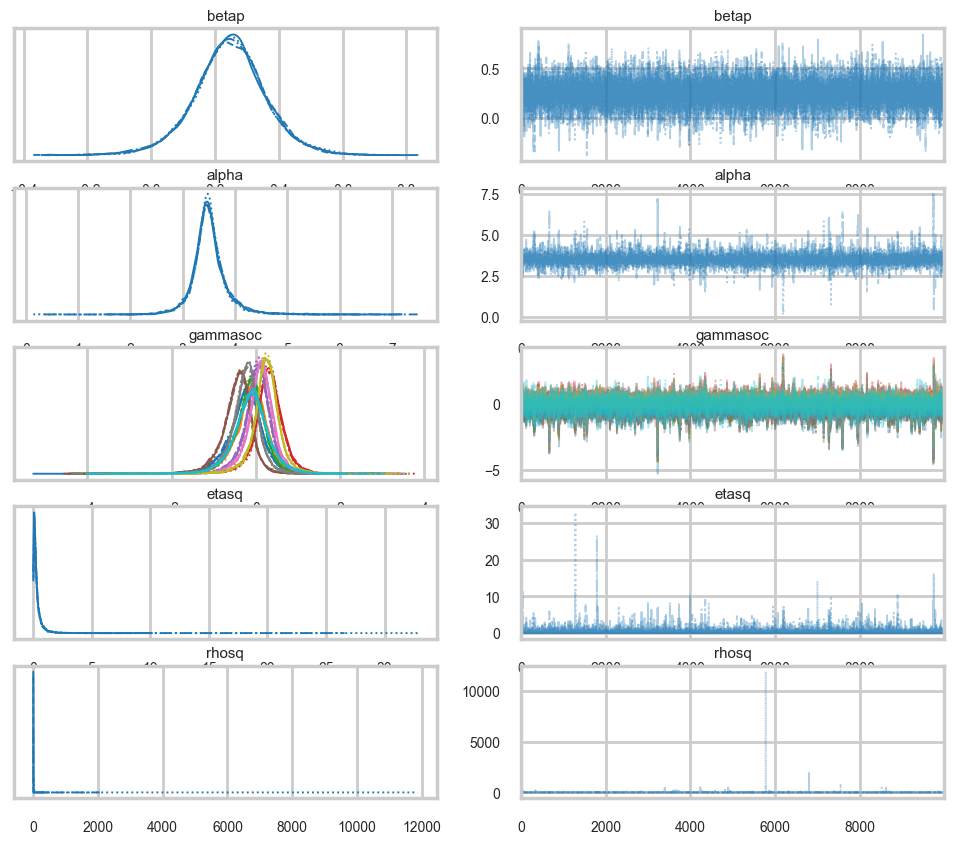

In [15]:
az.plot_trace(mgctrace);

/Users/rahul/Library/Caches/uv/archive-v0/aTiHGxSE8gD8G3bEQyxJO/lib/python3.14/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (56) in plot_autocorr, generating only 40 plots
  warnings.warn(


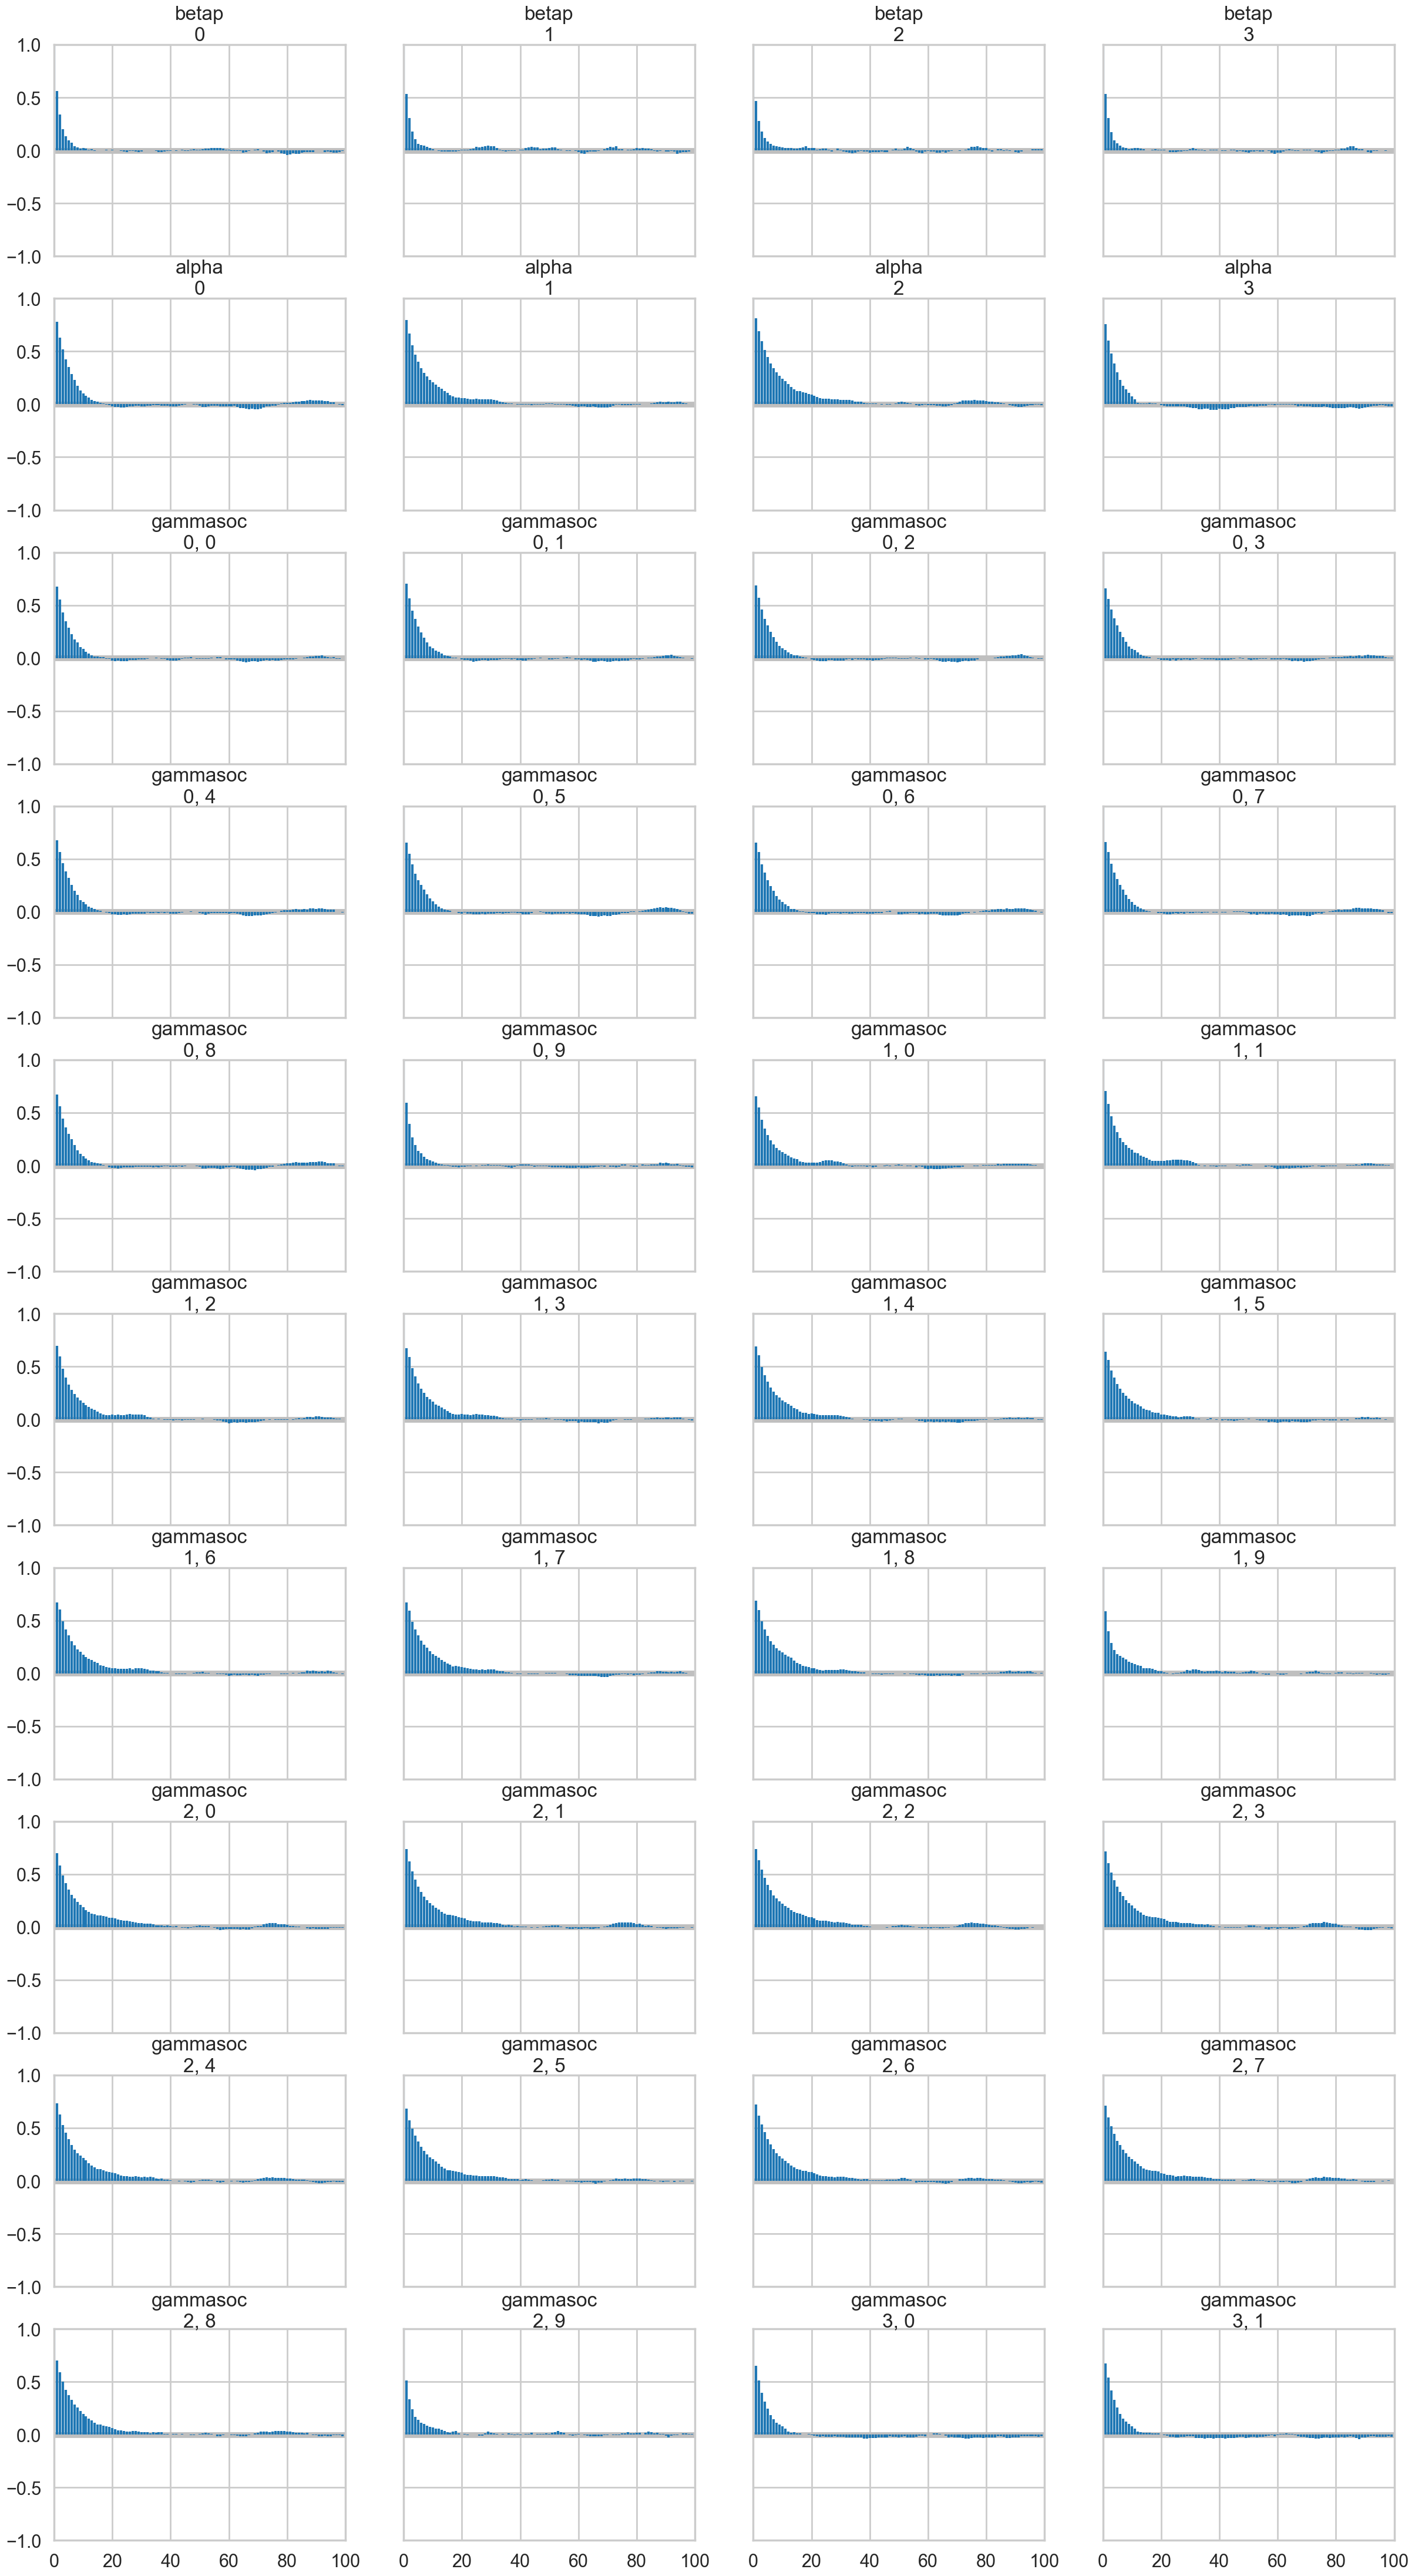

In [16]:
az.plot_autocorr(mgctrace);

In [17]:
d={}
gammasoc_samples = mgctrace.posterior['gammasoc'].values.reshape(-1, 10)
for i, v in enumerate(df.culture.values):
    d[v] = gammasoc_samples[:,i]
dfsamps=pd.DataFrame.from_dict(d)
dfsamps.head()

,Malekula,Tikopia,Santa Cruz,Yap,Lau Fiji,Trobriand,Chuuk,Manus,Tonga,Hawaii
0,-0.130590,0.089298,-0.181058,0.615596,0.044638,0.310527,0.318529,0.011540,0.522527,0.314769
1,-0.086934,0.260856,-0.154601,0.322845,0.349256,-0.795153,0.188721,-0.294910,0.368426,-0.112205
2,-0.032733,-0.008312,0.203633,0.255771,0.592531,-0.736068,0.244687,-0.314360,0.449234,-0.123681
3,-0.103811,-0.273942,0.047349,0.704714,0.157025,-0.358446,0.295830,0.189327,0.385959,0.165699
4,-0.138728,0.030216,-0.301498,0.259886,0.256591,-0.179903,0.237708,-0.223339,0.380631,0.238701


In [18]:
dfsamps.describe()

,Malekula,Tikopia,Santa Cruz,Yap,Lau Fiji,Trobriand,Chuuk,Manus,Tonga,Hawaii
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,-0.267976,-0.119667,-0.164049,0.300261,0.031830,-0.453667,0.102345,-0.257916,0.238663,-0.115166
std,0.455163,0.443377,0.427740,0.384622,0.378590,0.388457,0.373908,0.376287,0.356762,0.459638
min,-5.289634,-4.423674,-4.465862,-3.658895,-3.881839,-4.573565,-3.968056,-4.391581,-3.535199,-4.035076
25%,-0.494601,-0.337898,-0.363096,0.115944,-0.143074,-0.637728,-0.066815,-0.431598,0.076133,-0.363911
50%,-0.236810,-0.093558,-0.132354,0.309491,0.046415,-0.418354,0.116564,-0.231101,0.248910,-0.108310
75%,-0.008959,0.128550,0.076217,0.503830,0.229287,-0.231597,0.297074,-0.055373,0.422726,0.138756
max,3.642086,3.495336,3.480449,3.841792,3.590994,2.914655,3.495762,3.064075,3.666528,3.068279


## Plotting posteriors and predictives

Lets plot the covariance posteriors for the 100 random samples in the trace.

In [19]:
smalleta=np.random.choice(mgctrace.posterior['etasq'].values.flatten(), replace=False, size=100)
smallrho=np.random.choice(mgctrace.posterior['rhosq'].values.flatten(), replace=False, size=100)

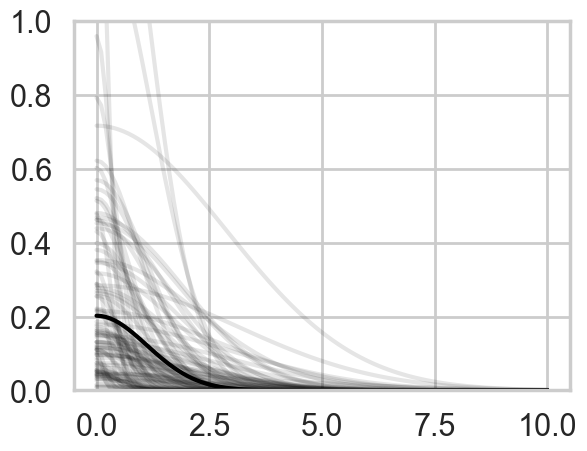

In [20]:
with sns.plotting_context('poster'):
    d=np.linspace(0,10,100)
    for i in range(100):
        covarod = lambda d: smalleta[i]*np.exp(-smallrho[i]*d*d)
        plt.plot(d, covarod(d),alpha=0.1, color='k')
    medetasq=np.median(mgctrace.posterior['etasq'].values.flatten())
    medrhosq=np.median(mgctrace.posterior['rhosq'].values.flatten())
    covarodmed = lambda d: medetasq*np.exp(-medrhosq*d*d)
    plt.plot(d, covarodmed(d),alpha=1.0, color='k', lw=3)
    plt.ylim([0,1]); 

The x-axis is thousands of kilometers. Notice how almost everything damps out by 4000 kms. Lets calculate the median correlation matrix:

In [21]:
medkij = np.diag([0.01]*10)+medetasq*(np.exp(-medrhosq*dij*dij))

In [22]:
#from statsmodels
def cov2corr(cov, return_std=False):
    '''convert covariance matrix to correlation matrix

    Parameters
    ----------
    cov : array_like, 2d
        covariance matrix, see Notes

    Returns
    -------
    corr : ndarray (subclass)
        correlation matrix
    return_std : bool
        If this is true then the standard deviation is also returned.
        By default only the correlation matrix is returned.

    Notes
    -----
    This function does not convert subclasses of ndarrays. This requires
    that division is defined elementwise. np.ma.array and np.matrix are allowed.

    '''
    cov = np.asanyarray(cov)
    std_ = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std_, std_)
    if return_std:
        return corr, std_
    else:
        return corr

In [23]:
medcorrij=cov2corr(medkij)
medcorrij

array([[1.00000000e+00, 8.69835262e-01, 8.11247323e-01, 4.34367364e-04,
        5.14947515e-01, 1.78423268e-01, 1.60816245e-02, 4.06297035e-02,
        2.35399591e-01, 2.09068998e-06],
       [8.69835262e-01, 1.00000000e+00, 9.15425265e-01, 8.36612901e-04,
        5.13920440e-01, 1.87081494e-01, 3.35913172e-02, 5.34275935e-02,
        2.00129903e-01, 1.20288892e-05],
       [8.11247323e-01, 9.15425265e-01, 1.00000000e+00, 2.31844903e-03,
        3.60868694e-01, 2.93087429e-01, 6.35978815e-02, 1.01103669e-01,
        1.16791052e-01, 7.22676264e-06],
       [4.34367364e-04, 8.36612901e-04, 2.31844903e-03, 1.00000000e+00,
        7.54894121e-06, 8.22482782e-02, 3.58611523e-01, 3.31644646e-01,
        2.34734649e-07, 8.62061048e-10],
       [5.14947515e-01, 5.13920440e-01, 3.60868694e-01, 7.54894121e-06,
        1.00000000e+00, 1.44642105e-02, 1.35724605e-03, 2.00050756e-03,
        7.53105751e-01, 6.19798877e-05],
       [1.78423268e-01, 1.87081494e-01, 2.93087429e-01, 8.22482782e-02,
   

We'll data frame it to see clearly

In [24]:
dfcorr = pd.DataFrame(medcorrij*100)
dfcorr.index = df.culture.tolist()
dfcorr.columns = df.culture.tolist()
dfcorr

,Malekula,Tikopia,Santa Cruz,Yap,Lau Fiji,Trobriand,Chuuk,Manus,Tonga,Hawaii
Malekula,100.000000,86.983526,81.124732,4.343674e-02,51.494751,17.842327,1.608162,4.062970,23.539959,2.090690e-04
Tikopia,86.983526,100.000000,91.542526,8.366129e-02,51.392044,18.708149,3.359132,5.342759,20.012990,1.202889e-03
Santa Cruz,81.124732,91.542526,100.000000,2.318449e-01,36.086869,29.308743,6.359788,10.110367,11.679105,7.226763e-04
Yap,0.043437,0.083661,0.231845,1.000000e+02,0.000755,8.224828,35.861152,33.164465,0.000023,8.620610e-08
Lau Fiji,51.494751,51.392044,36.086869,7.548941e-04,100.000000,1.446421,0.135725,0.200051,75.310575,6.197989e-03
Trobriand,17.842327,18.708149,29.308743,8.224828e+00,1.446421,100.000000,25.687280,71.158190,0.208418,1.621982e-06
Chuuk,1.608162,3.359132,6.359788,3.586115e+01,0.135725,25.687280,100.000000,52.575387,0.008986,1.261663e-04
Manus,4.062970,5.342759,10.110367,3.316446e+01,0.200051,71.158190,52.575387,100.000000,0.016959,1.117022e-06
Tonga,23.539959,20.012990,11.679105,2.347346e-05,75.310575,0.208418,0.008986,0.016959,100.000000,3.356022e-03
Hawaii,0.000209,0.001203,0.000723,8.620610e-08,0.006198,0.000002,0.000126,0.000001,0.003356,1.000000e+02


Notice how there is correlation in the upper left and with Manus and Trobriand. Mcelreath has a distance plot i reproduce below:

![Pacific island societies: geographic locations (left) and total tools vs log population with regression fits (right)](assets/pacisl.png)

To produce a plot like the one on the right, we calculate the posterior predictives with the correlation free part of the model and then overlay the correlations

In [25]:
from scipy.stats import poisson
def compute_pp_no_corr(lpgrid, idata, contact=0):
    alphatrace = idata.posterior['alpha'].values.flatten()
    betaptrace = idata.posterior['betap'].values.flatten()
    tl=len(alphatrace)
    gl=lpgrid.shape[0]
    lam = np.empty((gl, tl))
    lpgrid = lpgrid - lpgrid.mean()
    for i, v in enumerate(lpgrid):
        temp = alphatrace + betaptrace*lpgrid[i]
        lam[i,:] = poisson.rvs(np.exp(temp))
    return lam

In [26]:
lpgrid = np.linspace(6,13,30)
pp = compute_pp_no_corr(lpgrid, mgctrace)
ppmed = np.median(pp, axis=1)
pphpd = az.hdi(pp.T)

/var/folders/wq/mr3zj9r14dzgjnq9rjx_vqbc0000gn/T/ipykernel_99733/1140317622.py:4: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  pphpd = az.hdi(pp.T)


In [27]:
import itertools
corrs={}
for i, j in itertools.product(range(10), range(10)):
    if i <j:
        corrs[(i,j)]=medcorrij[i,j]
corrs

{(0, 1): np.float64(0.8698352620543791),
 (0, 2): np.float64(0.8112473227705732),
 (0, 3): np.float64(0.00043436736396140004),
 (0, 4): np.float64(0.5149475145540022),
 (0, 5): np.float64(0.1784232683108405),
 (0, 6): np.float64(0.016081624526447357),
 (0, 7): np.float64(0.04062970353128279),
 (0, 8): np.float64(0.23539959071681077),
 (0, 9): np.float64(2.0906899790788574e-06),
 (1, 2): np.float64(0.9154252648017558),
 (1, 3): np.float64(0.0008366129005128546),
 (1, 4): np.float64(0.5139204403538437),
 (1, 5): np.float64(0.18708149396439477),
 (1, 6): np.float64(0.03359131718569693),
 (1, 7): np.float64(0.053427593503310396),
 (1, 8): np.float64(0.20012990301592104),
 (1, 9): np.float64(1.202888923895069e-05),
 (2, 3): np.float64(0.0023184490292404336),
 (2, 4): np.float64(0.3608686936824079),
 (2, 5): np.float64(0.29308742903236046),
 (2, 6): np.float64(0.06359788152183848),
 (2, 7): np.float64(0.10110366922210785),
 (2, 8): np.float64(0.11679105204171875),
 (2, 9): np.float64(7.22676

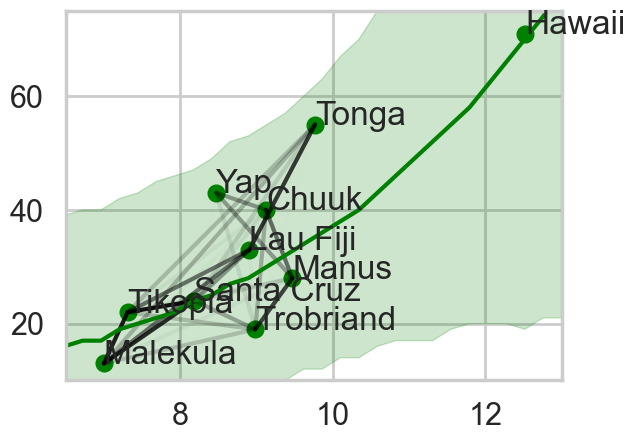

In [28]:
with sns.plotting_context('poster'):
    plt.plot(df.logpop, df.total_tools,'o', color="g")
    lpv = df.logpop.values
    ttv = df.total_tools.values
    for a,x,y in zip(df.culture.values, lpv, ttv):
        plt.annotate(a, xy=(x,y))
    for i in range(10):
        for j in range(10):
            if i < j:
                plt.plot([lpv[i],lpv[j]],[ttv[i], ttv[j]],'k', alpha=corrs[(i,j)]/1.)
    plt.plot(lpgrid, ppmed, color="g")
    plt.fill_between(lpgrid, pphpd[:,0], pphpd[:,1], color="g", alpha=0.2, lw=1)
    plt.ylim([10, 75])
    plt.xlim([6.5, 13])

Notice how distance probably pulls Fiji up from the median, and how Manus and Trobriand are below the median but highly correlated. A smaller effect can be seen with the triangle on the left. Of-course, causality is uncertain